In [1]:
import pandas as pd
import sqlite3
import re
import networkx as nx
import igraph as ig
import time
#import pycairo

In [2]:
# Connect to the SQLite database
conn = sqlite3.connect('/n/data1/hms/neurobio/wilson/banc/connectivity/frankenbrain_v.1.0_data.sqlite')

# List all tables in the database
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

# Print the tables
print("Tables in the database:", tables)

# Get the meta data, cell types, etc.
fw_meta = pd.read_sql_query("SELECT * FROM meta", conn)

# Group by cell_type, sort by top_p descending, and get the top_nt for each group
fw_meta = fw_meta.sort_values('top_p', ascending=False).groupby('cell_type').first().reset_index()

# Filter for tangential cells
fw_tangential = fw_meta[
    fw_meta['cell_type'].str.contains('CB.FB8|CB.FB7|CB.FB9') &
    fw_meta['cell_class'].isin(['central_complex', 'CX'])
]

# Filter for hDelta neurons
fw_hdelta = fw_meta[
    fw_meta['cell_type'].str.contains('hDeltaD') &
    fw_meta['cell_class'].isin(['central_complex', 'CX'])
]

# Collect the IDs we're interested in
tangential_ids = fw_tangential['root_783'].tolist()
hdelta_ids = fw_hdelta['root_783'].tolist()

# Construct the SQL query
query = f"""
SELECT *
FROM edgelist
WHERE count >= 15
  AND pre IN ({','.join(['?']*len(tangential_ids))})
  AND post IN ({','.join(['?']*len(hdelta_ids))})
"""

# Execute the query and collect the results
fw_elist_th = pd.read_sql_query(query, conn, params=tangential_ids + hdelta_ids)

# Close the database connection
conn.close()

Tables in the database: [('edgelist',), ('synapses',), ('meta',)]


### Fetch edgelist and graph creation

In [2]:
# check edgelist
# Connect to the SQLite database
conn = sqlite3.connect('/n/data1/hms/neurobio/wilson/banc/connectivity/frankenbrain_v.1.0_data.sqlite')
fw_elist = pd.read_sql_query("SELECT * FROM edgelist", conn)
# Close the database connection
conn.close()

: 

In [3]:
fw_elist.head()

,pre,post,post_label,count,pre_label,post_label_count,norm,pre_conf_nt,pre_conf_nt_p,post_conf_nt,post_conf_nt_p,pre_count,post_count,connection,index
0,720575940611335859,720575940600433181,axon,4,dendrite,566,0.0071,gaba,0.503,acetylcholine,0.98,255,101,dendrite-axon,1
1,720575940620863820,720575940600433181,axon,10,axon,566,0.0177,gaba,0.549,acetylcholine,0.98,409,101,axon-axon,2
2,720575940613229718,720575940600433181,axon,13,axon,566,0.0230,unknown,0,acetylcholine,0.98,296,101,axon-axon,3
3,720575940623090446,720575940600433181,axon,5,dendrite,566,0.0088,gaba,0.544,acetylcholine,0.98,702,101,dendrite-axon,4
4,720575940616946918,720575940600433181,axon,2,dendrite,566,0.0035,gaba,0.649,acetylcholine,0.98,741,101,dendrite-axon,5


In [4]:
# filtering 
# Step 1: Group by 'pre' and 'post' and calculate the sum of 'count'
fw_elistg = fw_elist.groupby(['pre', 'post'], as_index=False).agg(synaptic_count=('count', 'sum'))

# Step 2: Filter rows where 'synaptic_count' is greater than 25
fw_elistf = fw_elistg[fw_elistg['synaptic_count'] > 25]

fw_elistf.head()


,pre,post,synaptic_count
45,720575940600433181,720575940618524481,40
65,720575940600433181,720575940629552170,27
75,720575940600433181,720575940634877850,28
214,720575940602090976,720575940614740374,27
353,720575940602090976,720575940644438551,26


In [13]:
len(fw_elistf)

136995

In [16]:
# igraph
#subset_df = fw_elistf.sample(n=50000)
start_time = time.time()
g = ig.Graph.TupleList(fw_elistf[['pre', 'post']].itertuples(index=False), directed=True)
end_time = time.time()
print(f"Graph creation time: {end_time - start_time} seconds")

# Add weights if present
if 'synaptic_count' in fw_elistf.columns:
    g.es['synaptic_count'] = fw_elistf['synaptic_count'].tolist()


Graph creation time: 0.5749871730804443 seconds


In [17]:
print(g.summary())

IGRAPH DN-- 26183 136995 -- 
+ attr: name (v), synaptic_count (e)


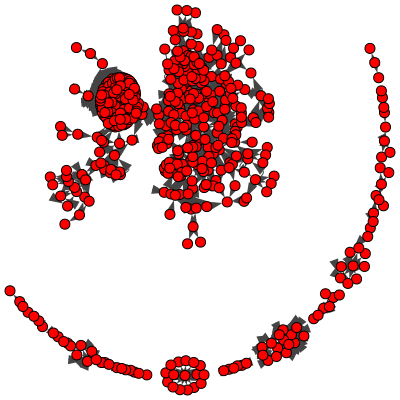

In [23]:
# Extract a subgraph for visualization (e.g., first 5 vertices)
subgraph_vertices = g.vs[:500]  # Selecting the first 100 vertices (you can modify this range)
subgraph = g.subgraph(subgraph_vertices)

# Visualize the subgraph
layout = subgraph.layout("kk")  # Kamada-Kawai layout for visualization
ig.plot(subgraph, layout=layout, vertex_size=10, bbox=(400, 400), margin=10)


In [ ]:
# TODO: ask Alex

# Assuming your edgelist is in a pandas DataFrame called 'df'
# Example of loading the edgelist table into a DataFrame (replace this with your actual data loading)
# Replace this part with actual DataFrame loading
data = {
    'pre': [720575940611335859, 720575940620863820, 720575940613229718, 720575940623090446, 720575940616946918],
    'post': [720575940600433181, 720575940600433181, 720575940600433181, 720575940600433181, 720575940600433181],
    'count': [4, 10, 13, 5, 2]
}

df = pd.DataFrame(data)

# Step 1: Create a directed graph from the edgelist
G = nx.DiGraph()

# Add edges to the graph (each connection in the edgelist)
for idx, row in df.iterrows():
    pre = row['pre']
    post = row['post']
    G.add_edge(pre, post)

# Step 2: Define the function to find the shortest path between two nodes
def find_shortest_path(pre_id, post_id):
    # Check if there is a direct connection (pre -> post)
    if G.has_edge(pre_id, post_id):
        return 0  # Direct connection, no intermediates needed

    try:
        # If not directly connected, find the shortest path
        # nx.shortest_path_length() will return the length of the shortest path
        path_length = nx.shortest_path_length(G, source=pre_id, target=post_id)
        return path_length
    except nx.NetworkXNoPath:
        # If no path exists between pre and post
        return float('inf')  # Return infinity if no path exists

# Example usage:
pre_id = 720575940611335859  # Replace with actual pre neuron ID
post_id = 720575940600433181  # Replace with actual post neuron ID

# Find the shortest path between pre and post
path_length = find_shortest_path(pre_id, post_id)
print(f"The shortest path length between {pre_id} and {post_id} is: {path_length}")


#### Query weight matrix directly

In [6]:
# query unique cell types in metadata
# List all unique cell types that contain 'PAM' or 'PPL'
mbdan_type = fw_meta[
    fw_meta['cell_type'].str.contains('PAM|PPL', case=False, na=False)
]['cell_type'].unique()[:-3]

# Print the unique PAM and PPL cell types
print("Unique cell types containing 'PAM' or 'PPL':")
for cell_type in mbdan_type:
    print(cell_type)


Unique cell types containing 'PAM' or 'PPL':
PAM01
PAM02
PAM03
PAM04
PAM05
PAM06
PAM07
PAM08
PAM09
PAM10
PAM11
PAM12
PAM13
PAM14
PAM15
PPL101
PPL102
PPL103
PPL104
PPL105
PPL106
PPL107
PPL108
PPL201
PPL202
PPL203
PPL204


In [7]:
# AN to DAN connections
# Fetch all neurons in fw_meta that are in the 'AN' cell class
fw_an = fw_meta[fw_meta['cell_class'] == 'AN']
# fetch MB DANs
fw_mbdan = fw_meta[fw_meta['cell_type'].isin(mbdan_type)]


In [13]:
# Collect the IDs we're interested in
an_ids = fw_an['root_783'].tolist()
mbdan_ids = fw_mbdan['root_783'].tolist()

# Construct the SQL query
query = f"""
SELECT *
FROM edgelist
WHERE count >= 15
  AND pre IN ({','.join(['?']*len(an_ids))})
  AND post IN ({','.join(['?']*len(mbdan_ids))})
"""

# Connect to the SQLite database
conn = sqlite3.connect('/n/data1/hms/neurobio/wilson/banc/connectivity/flywire_783_data.sqlite')

# Execute the query and collect the results
fw_elist_an_mbdan = pd.read_sql_query(query, conn, params=an_ids + mbdan_ids)

# Close the database connection
conn.close()

In [9]:
# AN to KC connections
fw_kc = fw_meta[fw_meta['cell_class'] == 'Kenyon_Cell']

an_ids = fw_an['root_783'].tolist()
kc_ids = fw_kc['root_783'].tolist()

# Construct the SQL query
query = f"""
SELECT *
FROM edgelist
WHERE count >= 15
  AND pre IN ({','.join(['?']*len(an_ids))})
  AND post IN ({','.join(['?']*len(kc_ids))})
"""

# Connect to the SQLite database
conn = sqlite3.connect('/n/data1/hms/neurobio/wilson/banc/connectivity/flywire_783_data.sqlite')

# Execute the query and collect the results
fw_elist_an_kc = pd.read_sql_query(query, conn, params=an_ids + kc_ids)

# Close the database connection
conn.close()

In [10]:
fw_elist_an_kc

,pre,post,post_label,count,pre_label,post_label_count,norm,pre_conf_nt,pre_conf_nt_p,post_conf_nt,post_conf_nt_p,pre_count,post_count,connection,index
